# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# CNN Model Building - Deep CNN

This project will do process of building various CNN models. We will build 3 CNN architecture with different complexity and compare the performance. For this notebook we will do deeper CNN model architecture than before.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Using CPU")

2026-02-01 18:46:14.578059: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU


## 1. Configuration & Setup

In [2]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
VAL_DIR = PROCESSED_DIR / 'val'
TEST_DIR = PROCESSED_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 100
NUM_CLASSES = 12

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Image size: (224, 224)
Batch size: 16
Epochs: 100


## 2. Data Generators with Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 8424 images belonging to 12 classes.
Found 1550 images belonging to 12 classes.
Found 1556 images belonging to 12 classes.
Train samples: 8424
Validation samples: 1550
Test samples: 1556


# 3. Build model architecture

For this deep CNN architecture we will build CNN with 5 convolutional blocks and ~8M parameters which is deeper than model in both medium and simple cnn notebook

In [4]:
def create_deep_cnn(input_shape=(224, 224, 3), num_classes=12):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='DeepCNN')
    
    return model

model = create_deep_cnn()
model.summary()

I0000 00:00:1769946421.475160    3292 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "DeepCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 28,584,620 (109.04 MB)

 Trainable params: 28,579,564 (109.02 MB)

 Non-trainable params: 5,056 (19.75 KB)

## 6. Training Configuration

In [5]:
def get_callbacks(model_name):
    model_path = MODELS_DIR / f'{model_name}_best.keras'
    
    callbacks_list = [
        callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callbacks_list

## 7. Training model

In [6]:
print("Training Deep CNN")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('deep_cnn'),
    verbose=1
)

print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Training Deep CNN
Started at: 2026-02-01 18:47:03
Epoch 1/100


2026-02-01 18:47:09.755328: I external/local_xla/xla/service/service.cc:163] XLA service 0x711f3c0218a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 18:47:09.755364: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-01 18:47:09.950082: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-01 18:47:10.803830: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-01 18:47:15.188362: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 790.04MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
I0000 00:00:1769946450.

527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.1748 - loss: 3.1060
Epoch 1: val_accuracy improved from None to 0.21548, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/deep_cnn_best.keras
527/527 ━━━━━━━━━━━━━━━━━━━━ 213s 353ms/step - accuracy: 0.2202 - loss: 2.7334 - val_accuracy: 0.2155 - val_loss: 2.5698 - learning_rate: 0.0010
Epoch 2/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3083 - loss: 2.1699
Epoch 2: val_accuracy improved from 0.21548 to 0.25806, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/deep_cnn_best.keras
527/527 ━━━━━━━━━━━━━━━━━━━━ 91s 173ms/step - accuracy: 0.3319 - loss: 2.0692 - val_accuracy: 0.2581 - val_loss: 2.4129 - learning_rate: 0.0010
Epoch 3/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.3843 - loss: 1.8583
Epoch 3: val_accuracy improved from 0.25806 to 0.36710, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/deep_cnn_best.

# 8. Training history plot

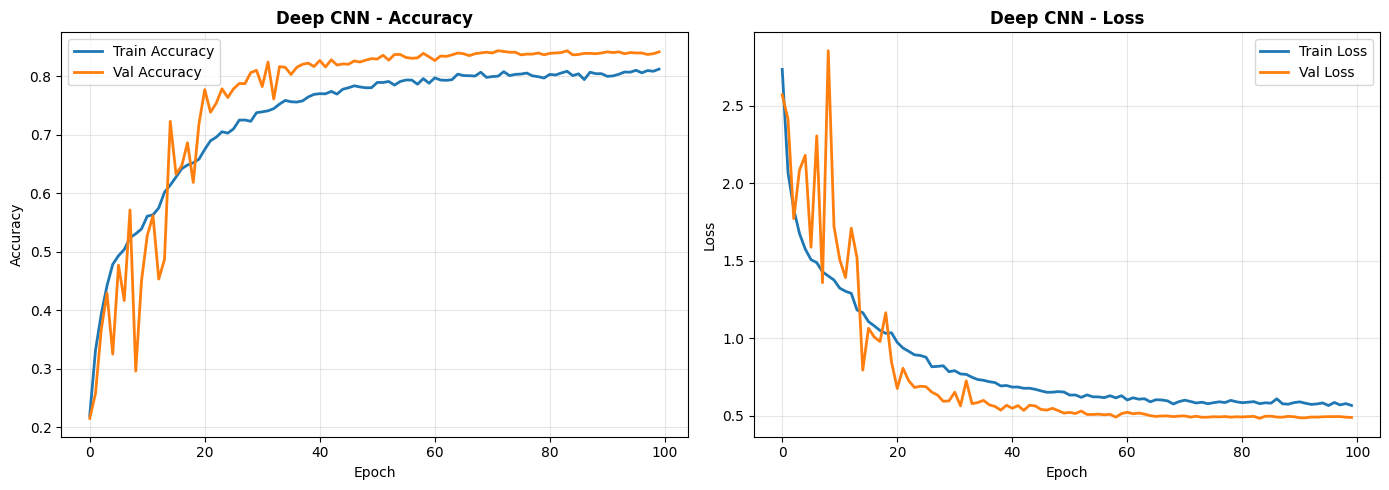

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Deep CNN - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Deep CNN - Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'deep_cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Save model and classification report

In [8]:
model.load_weights(str(MODELS_DIR / 'deep_cnn_best.keras'))

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print(f"\nDeep CNN Test Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(report)

98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step

Deep CNN Test Accuracy: 0.8361

Classification Report:
              precision    recall  f1-score   support

     battery     0.8351    0.8526    0.8438        95
  biological     0.8367    0.8283    0.8325        99
 brown-glass     0.8125    0.8525    0.8320        61
   cardboard     0.8587    0.8778    0.8681        90
     clothes     0.9408    0.8949    0.9173       533
 green-glass     0.8615    0.8889    0.8750        63
       metal     0.6404    0.7403    0.6867        77
       paper     0.7541    0.8762    0.8106       105
     plastic     0.6667    0.7586    0.7097        87
       shoes     0.8521    0.7273    0.7847       198
       trash     0.8983    0.7571    0.8217        70
 white-glass     0.6526    0.7949    0.7168        78

    accuracy                         0.8361      1556
   macro avg     0.8008    0.8208    0.8082      1556
weighted avg     0.8443    0.8361    0.8381      1556



# 10. Confussion matrix plot

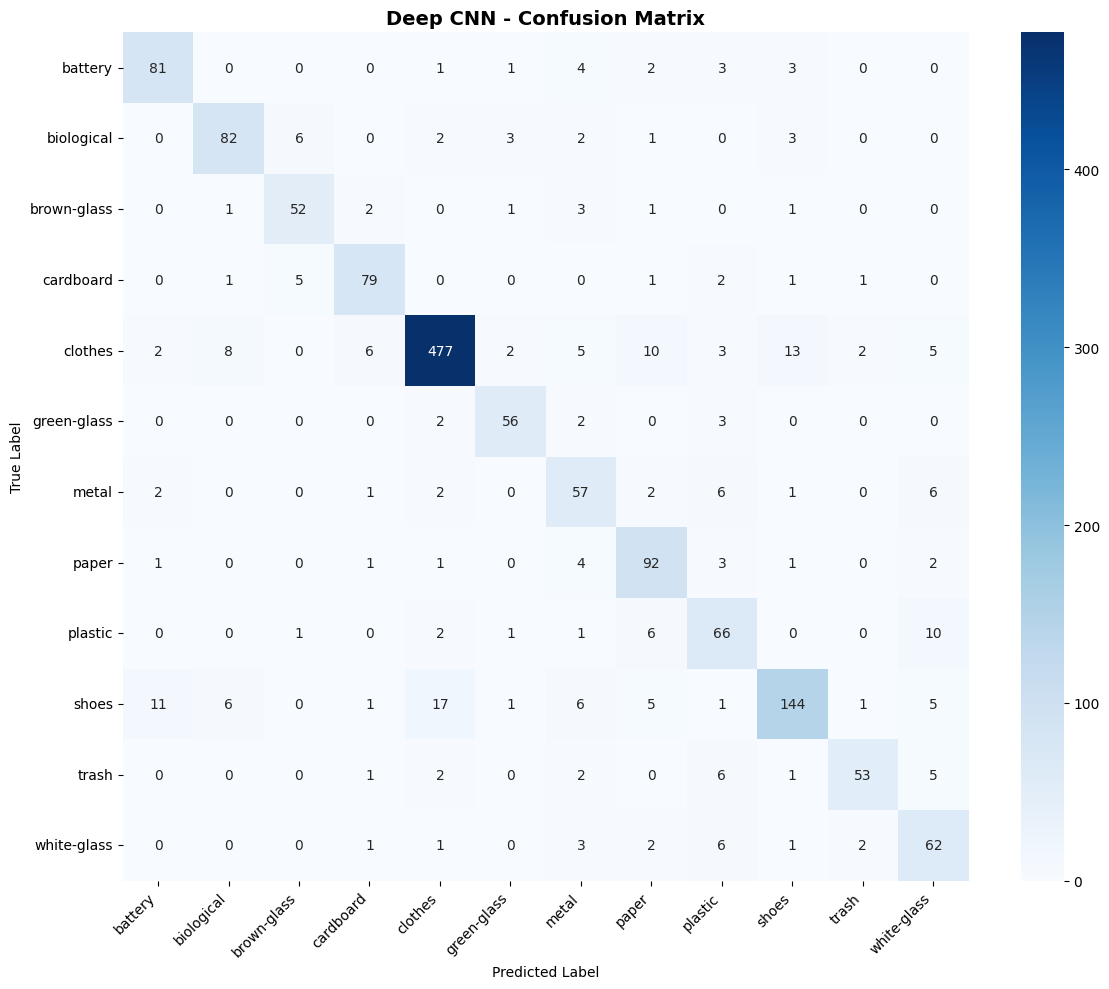

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deep CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'deep_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Summary

In [10]:
results = {
    'model_name': 'Deep CNN',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'parameters': int(model.count_params()),
    'test_accuracy': float(accuracy),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_train_accuracy': float(history.history['accuracy'][-1]),
    'epochs_trained': len(history.history['accuracy']),
    'configuration': {
        'image_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'max_epochs': EPOCHS
    }
}

with open(MODELS_DIR / 'deep_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to deep_cnn_results.json")
print(f"\nSummary:")
print(f"Parameters: {results['parameters']:,}")
print(f"Test Accuracy: {results['test_accuracy']:.4f}")
print(f"Best Val Accuracy: {results['best_val_accuracy']:.4f}")
print(f"Epochs Trained: {results['epochs_trained']}")

Results saved to deep_cnn_results.json

Summary:
Parameters: 28,584,620
Test Accuracy: 0.8361
Best Val Accuracy: 0.8439
Epochs Trained: 100
